# Pulsar performance: the numbers behind docs/performance.md

Every measured figure in [`docs/performance.md`](../docs/performance.md) is computed here, from the
files in [`results/`](results) and nothing else, except those marked "printed only", which have no raw
file and are listed in section 7. Every chart in `docs/assets/perf/` is drawn here. Run it top to
bottom from the repository root:

```
jupyter nbconvert --to notebook --execute --inplace bench/performance.ipynb
```

Conventions: a figure written `a ± b (n)` is the mean and the sample standard deviation (n − 1) of
n individual samples, never of per-run means. "Blocked" is the sum of long tasks (over 50 ms) the
page reported in a window after the action. What each file holds, and how it was measured, is in
[`results/README.md`](results/README.md).

In [1]:
from pathlib import Path
import gzip
import math
import re

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%config InlineBackend.figure_formats = ['png']

HERE = Path.cwd() if (Path.cwd() / 'results').is_dir() else Path.cwd() / 'bench'
RESULTS = HERE / 'results'
ASSETS = HERE.parent / 'docs' / 'assets' / 'perf'
ASSETS.mkdir(parents=True, exist_ok=True)

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 20)


def read(name):
    return pd.read_csv(RESULTS / name)


def stat(values):
    """Mean, sample sd and n of individual samples."""
    v = pd.Series(values, dtype=float).dropna()
    return pd.Series({'mean': v.mean(), 'sd': v.std(ddof=1), 'n': int(v.size)})


def table(df, by, col):
    out = df.groupby(by, sort=False)[col].apply(stat).unstack()
    out['n'] = out['n'].astype(int)
    return out


def pm(mean, sd, n=None, digits=2):
    text = f'{mean:.{digits}f} ± {sd:.{digits}f}'
    return f'{text} ({int(n)})' if n is not None else text


def keep_rule(before, after):
    """The keep rule: the mean moves by more than twice the sd of the 'before' samples."""
    b, a = pd.Series(before, dtype=float), pd.Series(after, dtype=float)
    moved = b.mean() - a.mean()
    return pd.Series({'before': b.mean(), 'after': a.mean(), 'moved': moved,
                      'sd_before': b.std(), 'moved_in_sd': moved / b.std(), 'kept': abs(moved) > 2 * b.std()})


RELEASES = ['1.38.0', '1.39.0', '1.40.0']

## Chart style

Two variants of every chart, one per GitHub theme, picked by `<picture>` in the markdown. The releases
are an ordered sequence, so they take one green ramp in Pulsar's own colour from the banner and icon:
older is dimmer, the newest is brightest, the way Pulsar draws notes. Pulsar off is a neutral grey.
Both ramps pass the ordinal checks (monotone lightness, visible steps, the faintest step at least 2:1
against the page) for their background. Every bar is also labelled on its axis and at its tip, so
colour is never the only way to tell builds apart.

In [2]:
THEMES = {
    'light': dict(text='#1f2328', muted='#59636e', grid='#d1d9e0', axis='#8c959f', off='#8c959f',
                  ramp=['#7cc596', '#2f9a59', '#11663a'], mid='#8fb59c', ink='#1f2328', page='#ffffff'),
    'dark': dict(text='#e6edf3', muted='#9198a1', grid='#30363d', axis='#6e7681', off='#6e7681',
                 ramp=['#2e7d4f', '#3dbd70', '#4dff91'], mid='#45694f', ink='#e6edf3', page='#0d1117'),
}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Segoe UI', 'Helvetica', 'Arial'],
    'font.size': 10,
    'svg.fonttype': 'none',
    'svg.hashsalt': 'pulsar-perf',
    'figure.dpi': 80,
    'axes.titlesize': 10.5,
    'axes.titleweight': 'bold',
    'axes.titlelocation': 'left',
})


def colour(build, t):
    if build in ('Pulsar off', 'off'):
        return t['off']
    if build in RELEASES:
        return t['ramp'][RELEASES.index(build)]
    return t['mid']


def style(ax, t, xlabel=None):
    ax.set_facecolor('none')
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)
    ax.spines['bottom'].set_color(t['axis'])
    ax.tick_params(colors=t['muted'], length=0, labelsize=9)
    ax.tick_params(axis='y', labelcolor=t['text'], labelsize=9.5)
    ax.xaxis.grid(True, color=t['grid'], linewidth=0.8)
    ax.set_axisbelow(True)
    ax.title.set_color(t['text'])
    if xlabel:
        ax.set_xlabel(xlabel, color=t['muted'], fontsize=9)


def hbars(ax, rows, t, unit, digits=2, xmax=None, note_fn=None):
    """Horizontal bars from zero, one row per build, whiskers at ±1 sd, value at the tip."""
    labels = [r['label'] for r in rows]
    y = np.arange(len(rows))[::-1]
    for yi, r in zip(y, rows):
        ax.barh(yi, r['mean'], height=0.58, color=r.get('color'), linewidth=0, zorder=2)
        if r.get('sd') is not None and r['sd'] > 0:
            ax.errorbar(r['mean'], yi, xerr=r['sd'], fmt='none', ecolor=t['ink'], elinewidth=1.1, capsize=3.5, capthick=1.1, zorder=3)
    ax.set_yticks(y, labels)
    ax.set_ylim(-0.6, len(rows) - 0.4)
    lim = xmax or max(r['mean'] + (r.get('sd') or 0) for r in rows) * 1.42
    ax.set_xlim(0, lim)
    for yi, r in zip(y, rows):
        end = r['mean'] + (r.get('sd') or 0)
        text = r.get('text') or (f"{r['mean']:.{digits}f} ± {r['sd']:.{digits}f} {unit}" if r.get('sd') is not None else f"{r['mean']:.{digits}f} {unit}")
        ax.text(end + lim * 0.015, yi, text, va='center', ha='left', fontsize=9, color=t['text'], zorder=4)


def caption(fig, t, title, sub):
    fig.text(0.012, 0.985, title, ha='left', va='top', fontsize=12, fontweight='bold', color=t['text'])
    fig.text(0.012, 0.985 - 0.085 * 4.2 / fig.get_figheight(), sub, ha='left', va='top', fontsize=9, color=t['muted'])


def save(draw, name, show=True):
    """Draws a chart once per theme and writes docs/assets/perf/<name>-<theme>.svg."""
    for theme, t in THEMES.items():
        fig = draw(t)
        fig.savefig(ASSETS / f'{name}-{theme}.svg', transparent=True, metadata={'Date': None})
        if show and theme == 'light':
            plt.show()
        plt.close(fig)
    return name

## 1. The one-session rerun: what was loaded, and the window it ran in

Pulsar off, 1.38.0, 1.39.0 and 1.40.0 measured side by side on 7 October 2026, 22:47–23:20 local
time (UTC−4), the order rotated every round and every run kept. Each run saved a metadata file beside
its results; `rerun/runs.csv` is those files.

In [3]:
builds = read('builds.csv')
runs = read('rerun/runs.csv')
display(builds)

measured = runs[runs.test != 'smoke']
on = measured[measured.loaded]
expected = dict(zip(builds.build, builds.main_sha256))
on_match = (on.main_sha256 == on.build.map(expected)).all()
print(f'metadata files: {len(runs)} ({len(measured)} measured runs and 1 smoke test)')
print(f'runs with Pulsar loaded: {len(on)}; every loaded main.js matches its release asset: {on_match}')
print(f"'off' runs: {len(measured[measured.build == 'Pulsar off'])}, Pulsar loaded in any of them: {measured[measured.build == 'Pulsar off'].loaded.any()}")
print(f'focused and visible in all: {bool((runs.focused & runs.visible & ~runs.minimized).all())}')
print(f'on battery in any: {bool(runs.on_battery.any())}; a GPU marked active in any: {bool(runs.gpu_marked_active.any())}')
print('display refresh by vault:', runs.groupby('vault').display_hz.unique().to_dict(), '| scale:', runs.display_scale.unique())
print(f'other Obsidian processes: {runs.other_obsidian_cores.min():.2f}–{runs.other_obsidian_cores.max():.2f} cores '
      f'(measured runs: {measured.other_obsidian_cores.min():.2f}–{measured.other_obsidian_cores.max():.2f})')
print(f"first and last run: {runs.at_utc.min()} … {runs.at_utc.max()}")
print('CPU:', runs.cpu.unique(), '| threads:', runs.threads.unique())

,build,kind,main_sha256,release_published_utc,commit,note
0,1.38.0,release,f17fcba711f0077c452473802d02d0b589a21994cddf5f...,2026-10-07T16:31:02Z,91861a2,the release asset; its sha256 matches GitHub's...
1,1.39.0,release,f4ecc4cce80b0f327b5aebb9c494694d25d8abca160cb3...,2026-10-07T22:06:00Z,9106c12,the release asset; its sha256 matches GitHub's...
2,1.40.0,release,423f54bae83b9e470fa883ec691c310157a311a0b0c108...,2026-10-08T00:55:48Z,ca3e4a5,the release asset; its sha256 matches GitHub's...
3,#108,pull request,NaN,NaN,b45a454,first session only; built from the branch; not...
4,#109,pull request,NaN,NaN,f70daa7,first session only; built from the branch; not...
5,#110,pull request,NaN,NaN,aec99c9,first session only; built from the branch; not...
6,#111,pull request,NaN,NaN,dc6f042,first session only; built from the branch; not...
7,#113,pull request,NaN,NaN,24978d0,first session only; the default branch before ...
8,#114,pull request,NaN,NaN,368ac23,first session only; built from the branch; not...
9,#116,pull request,NaN,NaN,448ba9c,first session only; built from the branch; not...


metadata files: 57 (56 measured runs and 1 smoke test)
runs with Pulsar loaded: 48; every loaded main.js matches its release asset: True
'off' runs: 8, Pulsar loaded in any of them: False
focused and visible in all: True
on battery in any: False; a GPU marked active in any: False
display refresh by vault: {'bench': array([165]), 'demo': array([59])} | scale: [1.25]
other Obsidian processes: 0.47–0.94 cores (measured runs: 0.50–0.94)
first and last run: 2026-10-08T02:47:55.643Z … 2026-10-08T03:19:21.679Z
CPU: <StringArray>
['AMD Ryzen 7 7735HS with Radeon Graphics']
Length: 1, dtype: str | threads: [16]


### 1.1 Opening the global graph, bench vault, 20,000 notes, the author's filter

In [4]:
opens = read('rerun/open.csv')
timed = opens[opens.purpose == 'timed'].copy()
timed['settled_s'] = timed.settled_ms / 1000
timed['blocked_s'] = timed.blocked_ms / 1000
order = ['Pulsar off'] + RELEASES

# The rotation, read back from the timestamps rather than from the script that intended it.
timed = timed.sort_values('at_utc')
print('build order per round:')
for rnd, g in timed.groupby('round'):
    print(f'  round {rnd}:', ' → '.join(g.build))

open_tbl = pd.concat({'settled_s': table(timed, 'build', 'settled_s'), 'blocked_s': table(timed, 'build', 'blocked_s'),
                      'to_first_nodes_ms': table(timed, 'build', 'to_first_nodes_ms')}, axis=1).loc[order]
display(open_tbl.round(3))

print('first build of each run: nodes in it, and every count seen in the first 3 s')
display(timed.groupby('build').agg(first_nodes=('first_nodes', lambda s: sorted(set(s))),
                                     counts=('node_counts_first_3s', lambda s: sorted(set(s)))).loc[order])

o = open_tbl
print(f"1.38.0 → 1.39.0: settled {o.loc['1.38.0', ('settled_s', 'mean')] / o.loc['1.39.0', ('settled_s', 'mean')]:.1f}× faster, "
      f"blocked {o.loc['1.38.0', ('blocked_s', 'mean')] / o.loc['1.39.0', ('blocked_s', 'mean')]:.0f}× less")
print(f"Pulsar off → 1.39.0: settled {o.loc['Pulsar off', ('settled_s', 'mean')] / o.loc['1.39.0', ('settled_s', 'mean')]:.1f}×, "
      f"blocked {o.loc['Pulsar off', ('blocked_s', 'mean')] / o.loc['1.39.0', ('blocked_s', 'mean')]:.0f}×")
off = timed[timed.build == 'Pulsar off'].settled_s.sort_values()
print('Pulsar off, settled, each run (s):', off.round(1).tolist())
print('Pulsar off without its slowest run:', pm(*stat(off.iloc[:-1])[:2], int(stat(off.iloc[:-1]).n), 1), 's')
k = keep_rule(timed[timed.build == '1.38.0'].blocked_s, timed[timed.build == '1.39.0'].blocked_s)
print(f'blocked 1.38.0 → 1.39.0: −{k.moved:.2f} s = {k.moved_in_sd:.1f} sd of before; kept: {k.kept}')

setup = opens[opens.purpose == 'before switches'].copy()
setup['settled_s'] = setup.settled_ms / 1000
print('cross-check: the 9 opens made before the note switches (not used above)')
display(table(setup, 'build', 'settled_s').round(2))

build order per round:
  round 1: Pulsar off → 1.38.0 → 1.39.0 → 1.40.0
  round 2: 1.38.0 → 1.39.0 → 1.40.0 → Pulsar off
  round 3: 1.39.0 → 1.40.0 → Pulsar off → 1.38.0
  round 4: 1.40.0 → Pulsar off → 1.38.0 → 1.39.0
  round 5: Pulsar off → 1.38.0 → 1.39.0 → 1.40.0
  round 6: 1.38.0 → 1.39.0 → 1.40.0 → Pulsar off


settled_s           blocked_s           to_first_nodes_ms           
                mean     sd  n      mean     sd  n              mean      sd  n
build                                                                          
Pulsar off    30.648  3.882  6    25.840  4.306  6           372.567  73.316  6
1.38.0        10.944  0.755  6     5.022  0.695  6           361.050  50.446  6
1.39.0         6.161  0.108  6     0.299  0.049  6           188.867   8.162  6
1.40.0         6.136  0.150  6     0.276  0.031  6           190.450   8.238  6

first build of each run: nodes in it, and every count seen in the first 3 s


,first_nodes,counts
build,,
Pulsar off,[20000],[20000]
1.38.0,[20000],[20000;4168]
1.39.0,[4168],[4168]
1.40.0,[4168],[4168]


1.38.0 → 1.39.0: settled 1.8× faster, blocked 17× less
Pulsar off → 1.39.0: settled 5.0×, blocked 87×
Pulsar off, settled, each run (s): [28.2, 28.2, 28.7, 29.4, 31.0, 38.3]
Pulsar off without its slowest run: 29.1 ± 1.2 (5) s
blocked 1.38.0 → 1.39.0: −4.72 s = 6.8 sd of before; kept: True
cross-check: the 9 opens made before the note switches (not used above)


,mean,sd,n
build,,,
1.38.0,10.02,0.07,3
1.39.0,6.23,0.13,3
1.40.0,6.27,0.22,3


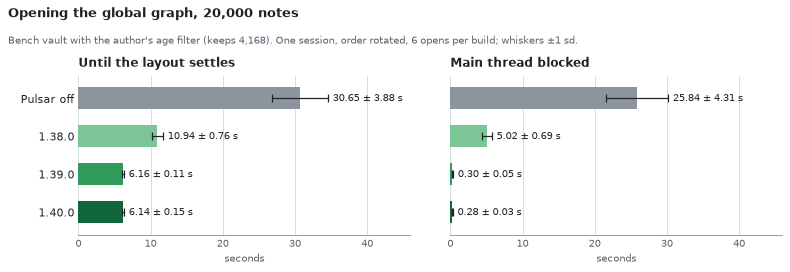

'open-20k'

In [5]:
def draw_open(t):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True)
    fig.subplots_adjust(left=0.1, right=0.98, top=0.74, bottom=0.17, wspace=0.12)
    for ax, col, title in ((axes[0], 'settled_s', 'Until the layout settles'), (axes[1], 'blocked_s', 'Main thread blocked')):
        rows = [dict(label=b, mean=o.loc[b, (col, 'mean')], sd=o.loc[b, (col, 'sd')], color=colour(b, t)) for b in order]
        hbars(ax, rows, t, 's', xmax=46)
        style(ax, t, 'seconds')
        ax.set_title(title, pad=8, color=t['text'])
    axes[1].tick_params(axis='y', labelleft=False)
    caption(fig, t, 'Opening the global graph, 20,000 notes',
            "Bench vault with the author's age filter (keeps 4,168). One session, order rotated, 6 opens per build; whiskers ±1 sd.")
    return fig


save(draw_open, 'open-20k')

### 1.2 A note switch, 4,168 nodes drawn

In [6]:
sw = read('rerun/switch.csv')
warm = sw[sw.warmup]
sw = sw[~sw.warmup]
print(f'{len(sw)} timed switches, {len(warm)} warm-up switches left out; nodes drawn:', sorted(sw.nodes_drawn.unique()))
print('refilters per switch (in range / out):', sw.groupby(['build', 'pair']).refilters_per_switch.mean().unstack().to_dict())
sw_tbl = pd.concat({'blocked_ms': table(sw, ['pair', 'build'], 'blocked_ms'),
                    'second_frame_ms': table(sw, ['pair', 'build'], 'second_frame_ms')}, axis=1)
display(sw_tbl.round(2))

print('per round, 1.38.0 in range, blocked:', sw[(sw.build == '1.38.0') & (sw.pair == 'in')].groupby('round').blocked_ms.mean().round(1).tolist())
for pair in ('in', 'out'):
    for a, b in (('1.38.0', '1.39.0'), ('1.39.0', '1.40.0')):
        k = keep_rule(sw[(sw.build == a) & (sw.pair == pair)].blocked_ms, sw[(sw.build == b) & (sw.pair == pair)].blocked_ms)
        print(f'{pair:>3} {a} → {b}: blocked {k.before:.1f} → {k.after:.1f} ms, −{k.moved:.1f} ms = {k.moved_in_sd:.2f} sd of before; kept: {k.kept}')

360 timed switches, 36 warm-up switches left out; nodes drawn: [np.int64(4168), np.int64(4169)]
refilters per switch (in range / out): {'in': {'1.38.0': 1.0, '1.39.0': 0.0, '1.40.0': 0.0}, 'out': {'1.38.0': 1.0, '1.39.0': 1.0, '1.40.0': 1.0}}


blocked_ms            second_frame_ms           
                  mean     sd   n            mean     sd   n
pair build                                                  
in   1.38.0     149.57  11.99  60          166.50  18.40  60
     1.39.0      78.35   7.15  60           91.66  12.12  60
     1.40.0      75.30   6.37  60           90.76  15.16  60
out  1.38.0     157.18   9.72  60          205.52  11.20  60
     1.39.0     119.00   7.53  60          166.83   9.68  60
     1.40.0     117.58   9.96  60          165.82  12.99  60

per round, 1.38.0 in range, blocked: [144.2, 148.5, 156.0]
 in 1.38.0 → 1.39.0: blocked 149.6 → 78.3 ms, −71.2 ms = 5.94 sd of before; kept: True
 in 1.39.0 → 1.40.0: blocked 78.3 → 75.3 ms, −3.0 ms = 0.43 sd of before; kept: False
out 1.38.0 → 1.39.0: blocked 157.2 → 119.0 ms, −38.2 ms = 3.93 sd of before; kept: True
out 1.39.0 → 1.40.0: blocked 119.0 → 117.6 ms, −1.4 ms = 0.19 sd of before; kept: False


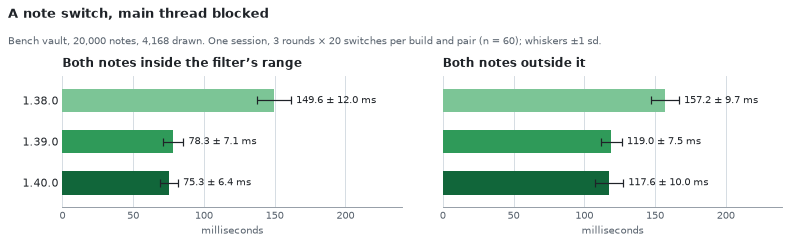

'switch-20k'

In [7]:
def draw_switch(t):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.1), sharex=True)
    fig.subplots_adjust(left=0.08, right=0.98, top=0.71, bottom=0.18, wspace=0.12)
    for ax, pair, title in ((axes[0], 'in', 'Both notes inside the filter’s range'), (axes[1], 'out', 'Both notes outside it')):
        rows = [dict(label=b, mean=sw_tbl.loc[(pair, b), ('blocked_ms', 'mean')], sd=sw_tbl.loc[(pair, b), ('blocked_ms', 'sd')],
                     color=colour(b, t)) for b in RELEASES]
        hbars(ax, rows, t, 'ms', digits=1, xmax=240)
        style(ax, t, 'milliseconds')
        ax.set_title(title, pad=8, color=t['text'])
    axes[1].tick_params(axis='y', labelleft=False)
    caption(fig, t, 'A note switch, main thread blocked',
            'Bench vault, 20,000 notes, 4,168 drawn. One session, 3 rounds × 20 switches per build and pair (n = 60); whiskers ±1 sd.')
    return fig


save(draw_switch, 'switch-20k')

### 1.3 A graph whose timelapse has run, at rest (demo vault)

all             round 1             round 2            
              mean      sd   n    mean      sd   n    mean      sd   n
build                                                                 
Pulsar off  0.0720  0.0049  40  0.0707  0.0022  20  0.0733  0.0064  20
1.38.0      0.3146  0.0193  40  0.3119  0.0173  20  0.3173  0.0213  20
1.39.0      0.0729  0.0055  40  0.0744  0.0071  20  0.0715  0.0027  20
1.40.0      0.0775  0.0202  40  0.0736  0.0039  20  0.0815  0.0281  20

share of 100 ms checks with the graph still drawing: {'Pulsar off': 0.0, '1.38.0': 1.0, '1.39.0': 0.0, '1.40.0': 0.0}
nodes drawn: {'Pulsar off': array([112]), '1.38.0': array([57]), '1.39.0': array([57]), '1.40.0': array([57])}
1.40.0 seconds above 0.15 cores: [{'round': 2, 'second': 6, 'renderer_cores': 0.1692, 'awake_share': 0}, {'round': 2, 'second': 7, 'renderer_cores': 0.1564, 'awake_share': 0}]
1.40.0 without them: 0.0730 ± 0.0037 (38) cores; 1.39.0 → 1.40.0 with them: 0.83 sd of 1.39.0


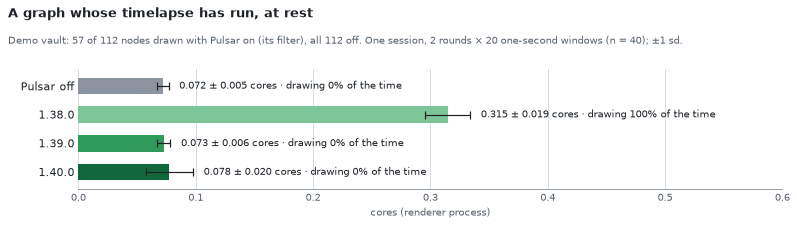

'timelapse'

In [8]:
tl = read('rerun/timelapse.csv')
display(pd.concat({'all': table(tl, 'build', 'renderer_cores'),
                   'round 1': table(tl[tl['round'] == 1], 'build', 'renderer_cores'),
                   'round 2': table(tl[tl['round'] == 2], 'build', 'renderer_cores')}, axis=1).loc[order].round(4))
print('share of 100 ms checks with the graph still drawing:', tl.groupby('build').awake_share.mean().loc[order].to_dict())
print('nodes drawn:', tl.groupby('build').nodes_drawn.unique().loc[order].to_dict())
tl_tbl = table(tl, 'build', 'renderer_cores').loc[order]
high = tl[(tl.build == '1.40.0') & (tl.renderer_cores > 0.15)]
print('1.40.0 seconds above 0.15 cores:', high[['round', 'second', 'renderer_cores', 'awake_share']].to_dict('records'))
rest = tl[(tl.build == '1.40.0') & (tl.renderer_cores <= 0.15)].renderer_cores
print(f'1.40.0 without them: {pm(rest.mean(), rest.std(), len(rest), 4)} cores; '
      f"1.39.0 → 1.40.0 with them: {(tl_tbl.loc['1.40.0', 'mean'] - tl_tbl.loc['1.39.0', 'mean']) / tl_tbl.loc['1.39.0', 'sd']:.2f} sd of 1.39.0")


def draw_timelapse(t):
    fig, ax = plt.subplots(figsize=(10, 2.9))
    fig.subplots_adjust(left=0.1, right=0.98, top=0.72, bottom=0.2)
    awake = tl.groupby('build').awake_share.mean()
    rows = []
    for b in order:
        m, s = tl_tbl.loc[b, 'mean'], tl_tbl.loc[b, 'sd']
        rows.append(dict(label=b, mean=m, sd=s, color=colour(b, t),
                         text=f"{m:.3f} ± {s:.3f} cores · drawing {awake[b]:.0%} of the time"))
    hbars(ax, rows, t, 'cores', xmax=0.6)
    style(ax, t, 'cores (renderer process)')
    caption(fig, t, 'A graph whose timelapse has run, at rest',
            'Demo vault: 57 of 112 nodes drawn with Pulsar on (its filter), all 112 off. One session, 2 rounds × 20 one-second windows (n = 40); ±1 sd.')
    return fig


save(draw_timelapse, 'timelapse')

### 1.4 Editor reconfigurations per load (demo vault, 6 editors open)

calls_per_load        ms_per_call        ms_per_load       whole_load_ms
defaults         1.38.0            [2]   4.58 ± 0.63 (20)   9.16 ± 1.03 (10)   56.06 ± 6.44 (10)
                 1.39.0            [2]   4.29 ± 0.58 (20)   8.57 ± 0.85 (10)  58.20 ± 13.73 (10)
                 1.40.0            [0]                NaN   0.00 ± 0.00 (10)   45.35 ± 3.30 (10)
fresh writing on 1.38.0            [2]   3.60 ± 0.51 (20)   7.20 ± 0.73 (10)   62.04 ± 7.69 (10)
                 1.39.0            [2]   4.22 ± 0.53 (20)   8.45 ± 0.62 (10)   69.62 ± 7.56 (10)
                 1.40.0            [1]  14.74 ± 1.58 (10)  14.74 ± 1.58 (10)   65.11 ± 4.37 (10)

editors open: [6]
fresh writing on: 1.40.0 − 1.38.0 = +7.54 ms per load
defaults: 1.38.0 − 1.40.0 = 9.16 ms per load in the calls
defaults, whole load 1.38.0 → 1.40.0: −10.7 ms = 1.7 sd of before; kept: False


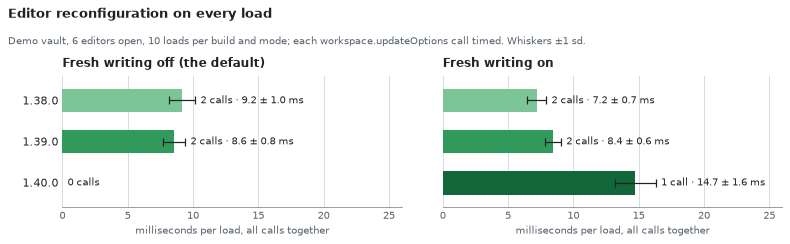

'reconfigure'

In [9]:
loads = read('rerun/reconfigure-loads.csv')
calls = read('rerun/reconfigure-calls.csv')
modes = ['defaults', 'fresh writing on']
rc = pd.DataFrame({
    'calls_per_load': loads.groupby(['mode', 'build']).calls.agg(lambda s: sorted(set(s))),
    'ms_per_call': calls.groupby(['mode', 'build']).ms.apply(lambda s: pm(*stat(s))),
    'ms_per_load': loads.groupby(['mode', 'build']).calls_ms.apply(lambda s: pm(*stat(s))),
    'whole_load_ms': loads.groupby(['mode', 'build']).enable_ms.apply(lambda s: pm(*stat(s))),
}).reindex(pd.MultiIndex.from_product([modes, RELEASES]))
display(rc)
print('editors open:', loads.editors.unique())
per_load = loads.groupby(['mode', 'build']).calls_ms.mean()
print(f"fresh writing on: 1.40.0 − 1.38.0 = {per_load[('fresh writing on', '1.40.0')] - per_load[('fresh writing on', '1.38.0')]:+.2f} ms per load")
print(f"defaults: 1.38.0 − 1.40.0 = {per_load[('defaults', '1.38.0')] - per_load[('defaults', '1.40.0')]:.2f} ms per load in the calls")
k = keep_rule(loads[(loads['mode'] == 'defaults') & (loads.build == '1.38.0')].enable_ms, loads[(loads['mode'] == 'defaults') & (loads.build == '1.40.0')].enable_ms)
print(f'defaults, whole load 1.38.0 → 1.40.0: −{k.moved:.1f} ms = {k.moved_in_sd:.1f} sd of before; kept: {k.kept}')


def draw_reconfigure(t):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.1), sharex=True)
    fig.subplots_adjust(left=0.08, right=0.98, top=0.71, bottom=0.18, wspace=0.12)
    for ax, mode, title in ((axes[0], 'defaults', 'Fresh writing off (the default)'), (axes[1], 'fresh writing on', 'Fresh writing on')):
        rows = []
        for b in RELEASES:
            g = loads[(loads['mode'] == mode) & (loads.build == b)]
            n_calls = int(g.calls.iloc[0])
            m, s = g.calls_ms.mean(), g.calls_ms.std()
            word = 'call' if n_calls == 1 else 'calls'
            rows.append(dict(label=b, mean=m, sd=s, color=colour(b, t),
                             text=f'{n_calls} {word} · {m:.1f} ± {s:.1f} ms' if n_calls else '0 calls'))
        hbars(ax, rows, t, 'ms', xmax=26)
        style(ax, t, 'milliseconds per load, all calls together')
        ax.set_title(title, pad=8, color=t['text'])
    axes[1].tick_params(axis='y', labelleft=False)
    caption(fig, t, 'Editor reconfiguration on every load',
            'Demo vault, 6 editors open, 10 loads per build and mode; each workspace.updateOptions call timed. Whiskers ±1 sd.')
    return fig


save(draw_reconfigure, 'reconfigure')

## 2. The first session: each fix against the build before it

Measured on 7 October, about 11:00–19:30, before the rerun. Build labels are the pull request that
build added. These files carry no build hash (T9 in the doc); the build was checked by md5 at the
time, and the check was printed rather than saved.

In [10]:
files = read('session1/files.csv')
files['local'] = pd.to_datetime(files.modified_utc) - pd.Timedelta(hours=4)


def when(pattern):
    t = files[files.label.str.match(pattern)].local
    return f"{t.min():%H:%M}–{t.max():%H:%M}"


print('first session, by the files\' modification times (UTC−4):', when('.'))
print('  1.38.0, #108, #109 note switches (H20k-*):', when('H20k-'), '| #110, #111 (R3-in/out-*):', when('R3-(in|out)-'))
gap = files.set_index('label').local
print(f"  1.38.0's two 20k switch baselines, 20k-his-switch-on and H20k-release-in: "
      f"{(gap['H20k-release-in'] - gap['20k-his-switch-on']).total_seconds() / 60:.0f} minutes apart")

first session, by the files' modification times (UTC−4): 11:20–18:41
  1.38.0, #108, #109 note switches (H20k-*): 13:46–13:50 | #110, #111 (R3-in/out-*): 17:50–17:58
  1.38.0's two 20k switch baselines, 20k-his-switch-on and H20k-release-in: 82 minutes apart


In [11]:
op1 = read('session1/open.csv')
op1['settled_s'] = op1.settled_ms / 1000
op1['blocked_s'] = op1.blocked_ms / 1000
for series, g in op1.groupby('series', sort=False):
    print(series)
    display(pd.concat({'settled_s': table(g, 'build', 'settled_s'), 'blocked_s': table(g, 'build', 'blocked_s')}, axis=1).round(3))
o20 = op1[op1.series == 'O20k']
print("#109's published table left out each arm's first run:")
display(pd.concat({'all runs': table(o20, 'build', 'settled_s'), 'without run 1': table(o20[o20.run > 1], 'build', 'settled_s')}, axis=1).round(1))
print(o20[o20.build == 'before #109'][['label', 'settled_ms', 'blocked_ms']])

FB20k


settled_s           blocked_s          
                mean     sd  n      mean     sd  n
build                                             
Pulsar off    32.340  1.851  6    27.802  1.763  6
#109          11.101  0.327  6     5.104  0.370  6
#110           6.208  0.068  6     0.254  0.019  6

O20k


settled_s           blocked_s           
                 mean     sd  n      mean      sd  n
build                                               
Pulsar off     34.032  7.610  6    28.486   7.235  6
#109           14.366  6.522  6     8.480   6.492  6
before #109    39.030    NaN  1    54.914  28.459  2

#109's published table left out each arm's first run:


all runs         without run 1        
                mean   sd  n          mean   sd  n
build                                             
Pulsar off      34.0  7.6  6          31.0  2.0  5
#109            14.4  6.5  6          11.7  1.1  5
before #109     39.0  NaN  1          39.0  NaN  1

        label  settled_ms  blocked_ms
30  O20k-on-1         NaN       75037
31  O20k-on-2     39029.7       34790


mean     sd   n
pair build                    
in   1.38.0  158.65   8.80  20
     #108    119.75   5.33  20
     #109    115.95   7.46  20
     #110    113.58   8.29  40
     #111     88.50   8.09  40
out  1.38.0  175.55   5.89  20
     #108    127.20   5.93  20
     #109    128.25   5.27  20
     #110    130.62  10.40  40
     #111    109.62   7.65  40

 in 1.38.0 → #108:  158.7 →  119.8 ms  (+38.9 ms, +4.42 sd)
 in   #108 → #109:  119.8 →  116.0 ms  (+3.8 ms, +0.71 sd)
 in   #109 → #110:  116.0 →  113.6 ms  (+2.4 ms, +0.32 sd)
 in   #110 → #111:  113.6 →   88.5 ms  (+25.1 ms, +3.02 sd)
out 1.38.0 → #108:  175.6 →  127.2 ms  (+48.4 ms, +8.21 sd)
out   #108 → #109:  127.2 →  128.2 ms  (-1.0 ms, -0.18 sd)
out   #109 → #110:  128.2 →  130.6 ms  (-2.4 ms, -0.45 sd)
out   #110 → #111:  130.6 →  109.6 ms  (+21.0 ms, +2.02 sd)
rounds 1 and 2 of #110/#111 were alternating; 1.38.0, #108 and #109 ran back to back, four hours earlier


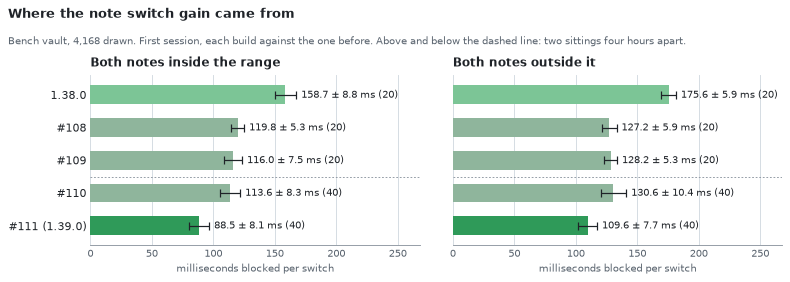

'switch-steps'

In [12]:
s1 = read('session1/switch-bench.csv')
steps = ['1.38.0', '#108', '#109', '#110', '#111']
s1_tbl = table(s1, ['pair', 'build'], 'blocked_ms')
display(s1_tbl.round(2))
for pair in ('in', 'out'):
    g = s1[s1.pair == pair]
    for a, b in zip(steps, steps[1:]):
        k = keep_rule(g[g.build == a].blocked_ms, g[g.build == b].blocked_ms)
        print(f'{pair:>3} {a:>6} → {b}: {k.before:6.1f} → {k.after:6.1f} ms  ({k.moved:+.1f} ms, {k.moved_in_sd:+.2f} sd)')
print('rounds 1 and 2 of #110/#111 were alternating; 1.38.0, #108 and #109 ran back to back, four hours earlier')


def draw_steps(t):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharex=True)
    fig.subplots_adjust(left=0.115, right=0.98, top=0.75, bottom=0.16, wspace=0.1)
    for ax, pair, title in ((axes[0], 'in', 'Both notes inside the range'), (axes[1], 'out', 'Both notes outside it')):
        rows = []
        for b in steps:
            m, s, n = s1_tbl.loc[(pair, b)]
            c = colour(b, t) if b == '1.38.0' else t['ramp'][1] if b == '#111' else t['mid']
            label = {'1.38.0': '1.38.0', '#111': '#111 (1.39.0)'}.get(b, b)
            rows.append(dict(label=label, mean=m, sd=s, color=c, text=f'{m:.1f} ± {s:.1f} ms ({int(n)})'))
        hbars(ax, rows, t, 'ms', xmax=268)
        ax.axhline(1.5, color=t['axis'], linewidth=0.8, linestyle=(0, (2, 2)))
        style(ax, t, 'milliseconds blocked per switch')
        ax.set_title(title, pad=8, color=t['text'])
    axes[1].tick_params(axis='y', labelleft=False)
    caption(fig, t, 'Where the note switch gain came from',
            'Bench vault, 4,168 drawn. First session, each build against the one before. Above and below the dashed line: two sittings four hours apart.')
    return fig


save(draw_steps, 'switch-steps')

applyTo_ms       syncRenderers_ms       spotlitFrom_ms       exemptFromFilter_ms       paintTabs_ms       keptWithoutOpen_ms       blocked_ms  \
                 mean   std             mean   std           mean   std                mean   std         mean   std               mean   std       mean   
pair build                                                                                                                                                 
in   #110       55.99  6.33            28.36  4.01           7.68  1.14                3.24  0.43         2.51  0.51               0.68  0.23     117.10   
     #111       29.25  5.36             0.06  0.05           5.32  0.89                1.91  0.48         2.39  0.41               0.66  0.20      94.48   
out  #110       55.24  4.57            27.96  3.48           6.81  0.65                3.26  0.36         2.05  0.34               0.57  0.14     126.02   
     #111       30.82  3.92             0.06  0.06           6.59  1.16                2.78  0.55         2.65  0.53               0.69  0.16     108.30   

                   
              std  
pair build         
in   #110   13.11  
     #111   22.37  
out  #110    8.16  
     #111   10.06

n per build and pair: [40]


,pair,round,note,nodes_110,nodes_111,nodes_differing
0,in,1,first,4168,4168,0
1,in,1,second,4168,4168,0
2,in,2,first,4168,4168,0
3,in,2,second,4168,4168,0
4,out,1,first,4168,4168,0
5,out,1,second,4169,4169,0
6,out,2,first,4168,4168,0
7,out,2,second,4169,4169,0


nodes differing between #110 and #111 after a settled switch: 0 across 8 snapshot pairs of 4168–4169 nodes


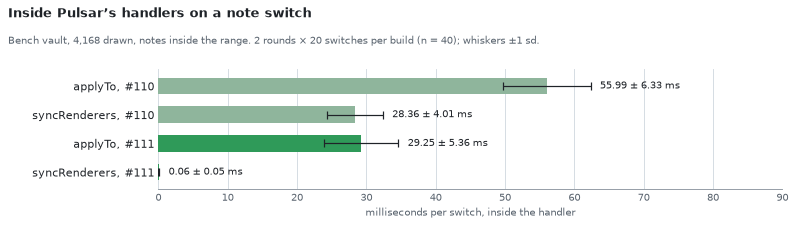

'switch-handlers'

In [13]:
hd = read('session1/switch-handlers.csv')
cols = ['applyTo_ms', 'syncRenderers_ms', 'spotlitFrom_ms', 'exemptFromFilter_ms', 'paintTabs_ms', 'keptWithoutOpen_ms']
hd_tbl = hd.groupby(['pair', 'build'])[cols + ['blocked_ms']].agg(['mean', 'std']).round(2)
display(hd_tbl)
print('n per build and pair:', hd.groupby(['pair', 'build']).size().unique())
paint = read('session1/paint-compare.csv')
display(paint)
print(f'nodes differing between #110 and #111 after a settled switch: {paint.nodes_differing.sum()} '
      f'across {len(paint)} snapshot pairs of {paint.nodes_110.min()}–{paint.nodes_110.max()} nodes')


def draw_handlers(t):
    fig, ax = plt.subplots(figsize=(10, 2.9))
    fig.subplots_adjust(left=0.2, right=0.98, top=0.72, bottom=0.2)
    rows = []
    g = hd[hd.pair == 'in']
    for b in ('#110', '#111'):
        for col, name in (('applyTo_ms', 'applyTo'), ('syncRenderers_ms', 'syncRenderers')):
            v = g[g.build == b][col]
            rows.append(dict(label=f'{name}, {b}', mean=v.mean(), sd=v.std(),
                             color=t['ramp'][1] if b == '#111' else t['mid'], text=f'{v.mean():.2f} ± {v.std():.2f} ms'))
    hbars(ax, rows, t, 'ms', xmax=90)
    style(ax, t, 'milliseconds per switch, inside the handler')
    caption(fig, t, 'Inside Pulsar’s handlers on a note switch',
            'Bench vault, 4,168 drawn, notes inside the range. 2 rounds × 20 switches per build (n = 40); whiskers ±1 sd.')
    return fig


save(draw_handlers, 'switch-handlers')

In [14]:
comp = read('session1/components.csv')
print('per-event jobs called on their own, 1.38.0 (aggregates as saved; sample = a batch of calls):')
display(comp[comp.step.isin(['refilter', 'syncRenderers'])].set_index(['vault', 'label', 'step'])[['calls_per_sample', 'n', 'mean_ms', 'sd_ms', 'median_ms']])

per-event jobs called on their own, 1.38.0 (aggregates as saved; sample = a batch of calls):


calls_per_sample   n  mean_ms  sd_ms  median_ms
vault     label                   step                                                          
demo      A-components            syncRenderers                11  30    0.254  0.052      0.255
                                  refilter                      3  30    0.504  0.166      0.533
bench 1k  1k-defaults-components  syncRenderers                 3  30    0.713  0.159      0.733
                                  refilter                      1  30    1.413  0.373      1.400
          1k-his-components       syncRenderers                 2  30    0.923  0.301      0.900
                                  refilter                      2  30    1.255  0.241      1.250
bench 5k  5k-defaults-components  syncRenderers                 1  30    4.463  1.416      4.200
                                  refilter                      1  30   14.183  1.703     14.000
bench 20k 20k-defaults-components syncRenderers                 1  20   23.195  1.753     22.900
                                  refilter                      1  20   84.150  4.345     84.500
          20k-his-components      syncRenderers                 1  20   28.105  2.323     28.700
                                  refilter                      1  20   45.840  9.147     44.100

In [15]:
f1 = read('session1/timelapse.csv')
display(table(f1, 'build', 'renderer_cores').round(4))
print('awake share:', f1.groupby('build').awake_share.mean().to_dict(), '| nodes:', f1.nodes_drawn.unique())

,mean,sd,n
build,,,
1.38.0,0.4097,0.0244,20
Pulsar off,0.0777,0.0165,20
#108,0.0762,0.0154,20
"#108, replay restarted",0.0768,0.0189,15


awake share: {'#108': 0.0, '#108, replay restarted': 0.0, '1.38.0': 1.0, 'Pulsar off': 0.0} | nodes: [112]


### 2.1 Changes that had to cost nothing

In [16]:
sd = read('session1/switch-demo.csv')
ks = read('session1/keystroke.csv')
ld = read('session1/load-demo.csv')
checks = []


def check(name, before, after, unit='ms'):
    k = keep_rule(before, after)
    checks.append(dict(change=name, before=pm(before.mean(), before.std(), len(before), 3 if unit == 'ms*' else 2),
                       after=pm(after.mean(), after.std(), len(after), 3 if unit == 'ms*' else 2),
                       after_pct=100 * after.mean() / before.mean(), moved_in_sd=k.moved_in_sd))


check('#111 · note switch, demo, second frame', sd[sd.build == '#110'].second_frame_ms, sd[sd.build == '#111'].second_frame_ms)
check('#113 · note switch, demo, second frame', sd[sd.build == '1.39.0'].second_frame_ms, sd[sd.build == '#113'].second_frame_ms)
check('#113 · note switch, demo, synchronous part', sd[sd.build == '1.39.0'].sync_ms, sd[sd.build == '#113'].sync_ms)
check('#114 · keystroke, demo', ks[ks.build == '#113'].ms, ks[ks.build == '#114'].ms, 'ms*')
check('#116 · load to next frame, demo, defaults', ld[(ld.build == 'before #116') & (ld['mode'] == 'defaults')].frame_ms,
      ld[(ld.build == '#116') & (ld['mode'] == 'defaults')].frame_ms)
check('#116 · load to next frame, demo, demo settings', ld[(ld.build == 'before #116') & (ld['mode'] == 'demo settings')].frame_ms,
      ld[(ld.build == '#116') & (ld['mode'] == 'demo settings')].frame_ms)
display(pd.DataFrame(checks).round(2))
print('keystroke per round:', ks.groupby(['build', 'round']).ms.mean().round(3).to_dict())

,change,before,after,after_pct,moved_in_sd
0,"#111 · note switch, demo, second frame",14.19 ± 1.56 (40),13.24 ± 1.51 (40),93.30,0.61
1,"#113 · note switch, demo, second frame",13.73 ± 1.72 (60),13.62 ± 1.59 (60),99.19,0.06
2,"#113 · note switch, demo, synchronous part",7.30 ± 1.07 (60),7.31 ± 1.12 (60),100.11,-0.01
3,"#114 · keystroke, demo",0.380 ± 0.242 (600),0.321 ± 0.178 (600),84.63,0.24
4,"#116 · load to next frame, demo, defaults",56.20 ± 10.06 (20),46.62 ± 12.50 (20),82.96,0.95
5,"#116 · load to next frame, demo, demo settings",72.80 ± 10.21 (20),66.20 ± 5.43 (20),90.93,0.65


keystroke per round: {('#113', 1): 0.452, ('#113', 2): 0.307, ('#114', 1): 0.358, ('#114', 2): 0.284}


## 3. What 1.38.0 cost against Pulsar off

The baseline every fix started from. Time from `setActiveLeaf` to the second animation frame after a
note switch, and the time of one frame of a moving graph. Defaults, except where the row says the
author's settings (whose filter keeps 4,168 of 20,000). The author's vault rows are aggregates only;
its raw files are not published.

,vault,nodes,on,off,diff_ms,on_over_off
0,demo,112,19.0 ± 1.7 (30),14.1 ± 1.8 (30),4.937,0.351
1,bench 1k,1000,23.5 ± 1.4 (30),20.6 ± 1.3 (30),2.853,0.138
2,bench 5k,5000,90.8 ± 8.0 (30),77.3 ± 5.7 (30),13.550,0.175
3,bench 20k,20000,371.2 ± 15.4 (20),324.1 ± 22.2 (20),47.085,0.145


,build,n,mean,sd,graphs_open
0,1.38.0,30,91.90,11.88,graph:241 (hidden);localgraph:1
2,Pulsar off,30,79.07,11.88,graph:1115 (hidden);localgraph:3
4,1.38.0 under the profiler,30,107.69,15.53,graph:241 (hidden);localgraph:1
6,Pulsar off under the profiler,30,88.65,11.22,graph:1115 (hidden);localgraph:3


every aggregate from the author's vault:


,metric,build,unit,n,mean,sd,median,source_label,graphs_open
0,"note switch, second frame",1.38.0,ms,30,91.897,11.877,91.650,A-switch-on,graph:241 (hidden);localgraph:1
1,"note switch, blocked",1.38.0,ms,30,1.833,10.042,0.000,A-switch-on,graph:241 (hidden);localgraph:1
2,"note switch, second frame",Pulsar off,ms,30,79.073,11.877,78.450,A-switch-off,graph:1115 (hidden);localgraph:3
3,"note switch, blocked",Pulsar off,ms,30,2.167,11.867,0.000,A-switch-off,graph:1115 (hidden);localgraph:3
4,"note switch, second frame",1.38.0 under the profiler,ms,30,107.693,15.533,106.750,B-switch-on,graph:241 (hidden);localgraph:1
5,"note switch, blocked",1.38.0 under the profiler,ms,30,15.867,24.715,0.000,B-switch-on,graph:241 (hidden);localgraph:1
6,"note switch, second frame",Pulsar off under the profiler,ms,30,88.647,11.224,89.700,B-switch-off,graph:1115 (hidden);localgraph:3
7,"note switch, blocked",Pulsar off under the profiler,ms,30,0.000,0.000,0.000,B-switch-off,graph:1115 (hidden);localgraph:3
8,"note switch, second frame",1.38.0,ms,30,82.810,8.716,81.050,H-switch-release,graph:241 (hidden);localgraph:1
9,"note switch, blocked",1.38.0,ms,30,1.700,9.311,0.000,H-switch-release,graph:241 (hidden);localgraph:1


the demo under the profiler: 20.3 ± 1.5 (30) on against 15.9 ± 1.6 (30) off


,mean,sd,n
vault,,,
bench 1k,25.7,1.3,30
bench 20k,179.8,12.1,20


,mean,sd,n
vault,,,
bench 1k,0.0,0.0,30
bench 20k,166.8,8.4,20


mean    sd    n
vault     build                                                           
demo      1.38.0                                           1.24  0.18  199
          Pulsar off                                       1.24  0.17  199
bench 1k  1.38.0                                           4.73  0.71  120
          Pulsar off                                       4.48  0.61  120
          1.38.0, author's settings                        1.04  0.18  120
bench 5k  1.38.0                                          23.61  1.60  119
          Pulsar off                                      23.28  1.42  119
bench 20k 1.38.0                                         103.04  7.78   59
          Pulsar off                                      98.41  5.27   59
          1.38.0, author's settings                       10.02  1.30   60
          1.38.0, author's settings, under the profiler    9.95  1.33  121

,metric,build,unit,n,mean,sd,median,source_label,graphs_open
14,"one frame of a moving graph, 1115 nodes","1.38.0, filter off in memory",ms,199,8.8196,1.0672,8.60,C-frame-on-1115,graph:1115
15,"one frame of a moving graph, 1115 nodes",Pulsar off,ms,200,7.8770,0.7944,7.75,C-frame-off-1115,graph:1115


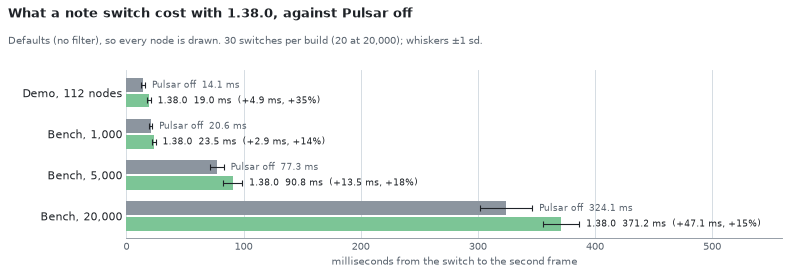

'baseline-switch'

In [17]:
bs = read('session1/baseline-switch.csv')
own = read('authors-vault.csv')
rows = []
for vault in ['demo', 'bench 1k', 'bench 5k', 'bench 20k']:
    g = bs[(bs.vault == vault) & (bs.pair.isin(['demo', 'defaults']))]
    on_ = g[g.build == '1.38.0'].second_frame_ms
    off_ = g[g.build == 'Pulsar off'].second_frame_ms
    nodes = int(g.nodes_drawn.iloc[0]) if g.nodes_drawn.notna().any() else None
    rows.append(dict(vault=vault, nodes=nodes, on=pm(on_.mean(), on_.std(), len(on_), 1), off=pm(off_.mean(), off_.std(), len(off_), 1),
                     diff_ms=on_.mean() - off_.mean(), on_over_off=on_.mean() / off_.mean() - 1, on_mean=on_.mean(), off_mean=off_.mean(),
                     on_sd=on_.std(), off_sd=off_.std()))
base = pd.DataFrame(rows)
display(base[['vault', 'nodes', 'on', 'off', 'diff_ms', 'on_over_off']].round(3))
# The author's vault is not like for like: with Pulsar on, its filter kept 241 of the 1,115 notes, and
# the global graph sat in a background tab in both arms, so only the local graph drew.
a = own[(own.metric == 'note switch, second frame') & own.source_label.isin(['A-switch-on', 'A-switch-off', 'B-switch-on', 'B-switch-off'])]
display(a[['build', 'n', 'mean', 'sd', 'graphs_open']].round(2))
print("every aggregate from the author's vault:")
display(own.round(3))
print('the demo under the profiler:', pm(*stat(bs[bs.build == '1.38.0 under the profiler'].second_frame_ms)[:2], 30, 1),
      'on against', pm(*stat(bs[bs.build == 'Pulsar off under the profiler'].second_frame_ms)[:2], 30, 1), 'off')
his = bs[bs.pair == "author's settings"]
display(table(his, 'vault', 'second_frame_ms').round(1))
display(table(his, 'vault', 'blocked_ms').round(1))

fr = read('session1/frame.csv')
display(table(fr, ['vault', 'build'], 'ms').round(2))
display(own[own.metric.str.startswith('one frame')])


def draw_baseline(t):
    fig, ax = plt.subplots(figsize=(10, 3.5))
    fig.subplots_adjust(left=0.16, right=0.98, top=0.76, bottom=0.16)
    order_v = ['demo', 'bench 1k', 'bench 5k', 'bench 20k']
    names = {'demo': 'Demo, 112 nodes', 'bench 1k': 'Bench, 1,000', 'bench 5k': 'Bench, 5,000', 'bench 20k': 'Bench, 20,000'}
    b = base.set_index('vault').loc[order_v]
    y = np.arange(len(order_v))[::-1] * 1.0
    h = 0.34
    for yi, (v, r) in zip(y, b.iterrows()):
        ax.barh(yi + h / 2 + 0.02, r.off_mean, height=h, color=t['off'], linewidth=0, zorder=2)
        ax.barh(yi - h / 2 - 0.02, r.on_mean, height=h, color=t['ramp'][0], linewidth=0, zorder=2)
        ax.errorbar(r.off_mean, yi + h / 2 + 0.02, xerr=r.off_sd, fmt='none', ecolor=t['ink'], elinewidth=1, capsize=3, zorder=3)
        ax.errorbar(r.on_mean, yi - h / 2 - 0.02, xerr=r.on_sd, fmt='none', ecolor=t['ink'], elinewidth=1, capsize=3, zorder=3)
        ax.text(r.on_mean + r.on_sd + 6, yi - h / 2 - 0.02, f'1.38.0  {r.on_mean:.1f} ms  (+{r.diff_ms:.1f} ms, +{r.on_over_off:.0%})',
                va='center', fontsize=8.5, color=t['text'])
        ax.text(r.off_mean + r.off_sd + 6, yi + h / 2 + 0.02, f'Pulsar off  {r.off_mean:.1f} ms', va='center', fontsize=8.5, color=t['muted'])
    ax.set_yticks(y, [names[v] for v in order_v])
    ax.set_xlim(0, 560)
    style(ax, t, 'milliseconds from the switch to the second frame')
    caption(fig, t, 'What a note switch cost with 1.38.0, against Pulsar off',
            "Defaults (no filter), so every node is drawn. 30 switches per build (20 at 20,000); whiskers ±1 sd.")
    return fig


save(draw_baseline, 'baseline-switch')

## 4. Every timed operation on one scale

From a keystroke to opening a 20,000-note graph: the latest measured build of each operation against
the oldest, on one logarithmic axis so that both ends fit. Dots are means, whiskers ±1 sd.

,operation,vault,before,after,off
0,"Open the global graph, until settled",bench 20k,1.38.0: 10943.500 ± 755.090 (6),1.40.0: 6135.983 ± 149.833 (6),30647.933 ± 3882.106 (6)
1,"Open the global graph, blocked",bench 20k,1.38.0: 5022.500 ± 694.512 (6),1.40.0: 276.333 ± 30.807 (6),25839.833 ± 4306.366 (6)
2,"Note switch, blocked, out of range",bench 20k,1.38.0: 157.183 ± 9.721 (60),1.40.0: 117.583 ± 9.965 (60),
3,"Note switch, blocked, in range",bench 20k,1.38.0: 149.567 ± 11.992 (60),1.40.0: 75.300 ± 6.373 (60),
4,"Plugin load, whole, fresh writing on",demo,1.38.0: 62.040 ± 7.686 (10),1.40.0: 65.110 ± 4.367 (10),
5,"Editor reconfiguration per load, fresh writing on",demo,1.38.0: 7.200 ± 0.733 (10),1.40.0: 14.740 ± 1.583 (10),
6,"Note switch, second frame",demo,#110: 14.188 ± 1.555 (40),#111: 13.238 ± 1.513 (40),14.057 ± 1.812 (30)
7,"One frame of a moving graph, 4,168 nodes",bench 20k,1.38.0: 10.017 ± 1.303 (60),1.38.0: 10.017 ± 1.303 (60),
8,"Timelapse graph at rest, CPU per second",demo,1.38.0: 314.610 ± 19.346 (40),1.40.0: 77.530 ± 20.193 (40),71.985 ± 4.867 (40)
9,"Refilter, one call",author's vault (aggregate),1.38.0: 1.162 ± 0.253 (30),#108: 0.343 ± 0.048 (30),


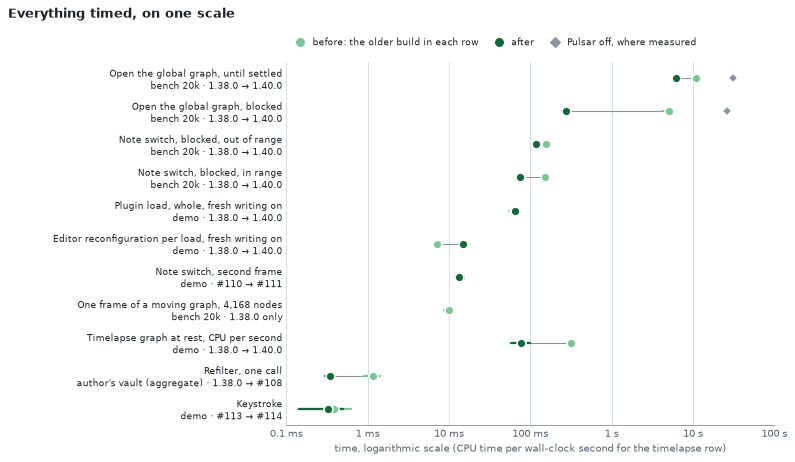

'scale'

In [18]:
ops = []


def op(name, sub, before_label, before, after_label, after, off=None, unit_ms=1.0):
    ops.append(dict(name=name, sub=sub, bl=before_label, b=stat(np.asarray(before) * unit_ms),
                    al=after_label, a=stat(np.asarray(after) * unit_ms), off=None if off is None else stat(np.asarray(off) * unit_ms)))


T = timed.set_index('build')
op('Open the global graph, until settled', 'bench 20k', '1.38.0', T.loc['1.38.0'].settled_ms, '1.40.0', T.loc['1.40.0'].settled_ms, T.loc['Pulsar off'].settled_ms)
op('Open the global graph, blocked', 'bench 20k', '1.38.0', T.loc['1.38.0'].blocked_ms, '1.40.0', T.loc['1.40.0'].blocked_ms, T.loc['Pulsar off'].blocked_ms)
S = sw.set_index(['pair', 'build']).sort_index()
op('Note switch, blocked, out of range', 'bench 20k', '1.38.0', S.loc[('out', '1.38.0')].blocked_ms, '1.40.0', S.loc[('out', '1.40.0')].blocked_ms)
op('Note switch, blocked, in range', 'bench 20k', '1.38.0', S.loc[('in', '1.38.0')].blocked_ms, '1.40.0', S.loc[('in', '1.40.0')].blocked_ms)
L = loads.set_index(['mode', 'build']).sort_index()
op('Plugin load, whole, fresh writing on', 'demo', '1.38.0', L.loc[('fresh writing on', '1.38.0')].enable_ms, '1.40.0', L.loc[('fresh writing on', '1.40.0')].enable_ms)
op('Editor reconfiguration per load, fresh writing on', 'demo', '1.38.0', L.loc[('fresh writing on', '1.38.0')].calls_ms, '1.40.0', L.loc[('fresh writing on', '1.40.0')].calls_ms)
op('Note switch, second frame', 'demo', '#110', sd[sd.build == '#110'].second_frame_ms, '#111', sd[sd.build == '#111'].second_frame_ms,
   bs[(bs.vault == 'demo') & (bs.build == 'Pulsar off')].second_frame_ms)
op('One frame of a moving graph, 4,168 nodes', 'bench 20k', '1.38.0', fr[fr.label == '20k-his-frame-on'].ms, '1.38.0', fr[fr.label == '20k-his-frame-on'].ms)
op('Timelapse graph at rest, CPU per second', 'demo', '1.38.0', tl[tl.build == '1.38.0'].renderer_cores, '1.40.0', tl[tl.build == '1.40.0'].renderer_cores,
   tl[tl.build == 'Pulsar off'].renderer_cores, unit_ms=1000)
g_ = own[own.metric == 'one call: refilter'].set_index('build')
ops.append(dict(name='Refilter, one call', sub="author's vault (aggregate)", bl='1.38.0', b=g_.loc['1.38.0', ['mean', 'sd', 'n']],
                al='#108', a=g_.loc['#108', ['mean', 'sd', 'n']], off=None))
op('Keystroke', 'demo', '#113', ks[ks.build == '#113'].ms, '#114', ks[ks.build == '#114'].ms)
display(pd.DataFrame([dict(operation=o_['name'], vault=o_['sub'], before=f"{o_['bl']}: {pm(*o_['b'][:2], o_['b'].n, 3)}",
                           after=f"{o_['al']}: {pm(*o_['a'][:2], o_['a'].n, 3)}",
                           off='' if o_['off'] is None else pm(*o_['off'][:2], o_['off'].n, 3)) for o_ in ops]))


def draw_scale(t):
    fig, ax = plt.subplots(figsize=(10, 5.9))
    fig.subplots_adjust(left=0.36, right=0.97, top=0.87, bottom=0.1)
    y = np.arange(len(ops))[::-1]
    for yi, o_ in zip(y, ops):
        same = o_['bl'] == o_['al']
        pts = [(o_['b'], t['ramp'][0], 'o')] if same else [(o_['b'], t['ramp'][0], 'o'), (o_['a'], t['ramp'][2], 'o')]
        if o_['off'] is not None:
            ax.plot([o_['off']['mean']], [yi], marker='D', ms=6.5, color=t['off'], zorder=3, linestyle='none', markeredgecolor=t['page'], markeredgewidth=1.5)
        if not same:
            ax.plot([o_['b']['mean'], o_['a']['mean']], [yi, yi], color=t['axis'], linewidth=1, zorder=2)
        for s_, c, m in pts:
            lo, hi = s_['mean'] - s_['sd'], s_['mean'] + s_['sd']
            assert lo > 0.1, o_['name']
            ax.plot([lo, hi], [yi, yi], color=c, linewidth=2, solid_capstyle='round', zorder=3)
            ax.plot([s_['mean']], [yi], marker=m, ms=8, color=c, zorder=4, linestyle='none', markeredgecolor=t['page'], markeredgewidth=1.5)
    ax.set_xscale('log')
    ax.set_xlim(0.1, 100000)
    ticks = [0.1, 1, 10, 100, 1000, 10000, 100000]
    ax.set_xticks(ticks, ['0.1 ms', '1 ms', '10 ms', '100 ms', '1 s', '10 s', '100 s'])
    ax.xaxis.set_minor_locator(matplotlib.ticker.NullLocator())
    ax.set_yticks(y, [f"{o_['name']}\n{o_['sub']} · {o_['bl']} → {o_['al']}" if o_['bl'] != o_['al'] else f"{o_['name']}\n{o_['sub']} · {o_['al']} only" for o_ in ops], fontsize=8.5)
    style(ax, t, 'time, logarithmic scale (CPU time per wall-clock second for the timelapse row)')
    ax.tick_params(axis='y', labelsize=8.5)
    from matplotlib.lines import Line2D
    handles = [Line2D([], [], marker='o', ms=7, color=t['ramp'][0], linestyle='none', label='before: the older build in each row'),
               Line2D([], [], marker='o', ms=7, color=t['ramp'][2], linestyle='none', label='after'),
               Line2D([], [], marker='D', ms=6, color=t['off'], linestyle='none', label='Pulsar off, where measured')]
    leg = fig.legend(handles=handles, loc='upper left', bbox_to_anchor=(0.355, 0.94), ncol=3, frameon=False, fontsize=8.5, handletextpad=0.3, columnspacing=1.2)
    for text in leg.get_texts():
        text.set_color(t['text'])
    fig.text(0.012, 0.985, 'Everything timed, on one scale', ha='left', va='top', fontsize=12, fontweight='bold', color=t['text'])
    return fig


save(draw_scale, 'scale')

## 5. CPU profiles

Folded stacks from the Chrome DevTools profiler sampling every 100 µs, idle time dropped. A frame's
owner is read from its file: `[plugin:pulsar-graph]` is Pulsar, `app.js`, `pixi.min.js`, `enhance.js`
and `i18next.min.js` are Obsidian, other bracketed files are Node and Electron, `(program)` and
`(garbage collector)` are the VM, and anything without a file is a browser built-in (WebGL, DOM) or
the harness's own code. Pulsar wraps Obsidian's render callback, so much of Obsidian's drawing sits
under a Pulsar frame: "self" counts only samples whose innermost frame is Pulsar's.

In [19]:
profiles = read('flame/profiles.csv').set_index('profile')
OBSIDIAN = {'app.js', 'pixi.min.js', 'enhance.js', 'i18next.min.js'}


def owner(frame):
    m = re.search(r' \[([^\]]*)\]$', frame)
    if m is None:
        return 'vm' if frame.startswith('(') else 'browser'
    where = m.group(1)
    if where == 'plugin:pulsar-graph':
        return 'pulsar'
    return 'obsidian' if where in OBSIDIAN else 'runtime'


def folded(name):
    with gzip.open(RESULTS / 'flame' / f'{name}.folded.gz', 'rt') as f:
        for line in f:
            stack, _, us = line.rstrip('\n').rpartition(' ')
            yield stack.split(';'), int(us)


split = []
for name, p in profiles.iterrows():
    total = own_ = calls_ = wrapped = 0
    for frames, us in folded(name):
        total += us
        owners = [owner(f) for f in frames]
        if owners[-1] == 'pulsar':
            own_ += us
        elif 'pulsar' in owners:
            last = max(i for i, w in enumerate(owners) if w == 'pulsar')
            if all(w in ('browser', 'runtime') for w in owners[last + 1:]):
                calls_ += us
            else:
                wrapped += us
    e = p.events
    split.append(dict(profile=name, build=p.build, event=p.event, events=e, busy_ms_per_event=total / 1000 / e,
                      pulsar_self=own_ / 1000 / e, under_a_pulsar_frame=(calls_ + wrapped) / 1000 / e,
                      check_busy=abs(total / 1000 - p.busy_ms) < 1))
split = pd.DataFrame(split).set_index('profile')
display(split.round(2))

,build,event,events,busy_ms_per_event,pulsar_self,under_a_pulsar_frame,check_busy
profile,,,,,,,
demo-switch-on,1.38.0,note switch,32,143.71,5.15,56.45,True
demo-switch-off,Pulsar off,note switch,32,119.35,1.12,14.79,True
demo-timelapse-on,1.38.0,second at rest,65,319.38,6.91,221.07,True
demo-timelapse-off,Pulsar off,second at rest,65,41.27,0.00,0.00,True
demo-load,1.38.0,plugin load,11,747.53,22.43,388.81,True
bench-switch,#109,note switch,14,890.70,226.04,514.59,True
bench-frame,1.38.0,frame,131,10.70,1.81,7.79,True


In [20]:
def top_self(name, who='pulsar', k=8):
    acc = {}
    for frames, us in folded(name):
        if owner(frames[-1]) == who:
            acc[frames[-1]] = acc.get(frames[-1], 0) + us
    e = profiles.loc[name, 'events']
    return pd.Series({f.replace(' [plugin:pulsar-graph]', ''): v / 1000 / e for f, v in sorted(acc.items(), key=lambda kv: -kv[1])[:k]}).round(2)


# The double paint #111 removed: the two routes into applyTo per switch in the #109 build.
routes = {}
for frames, us in folded('bench-switch'):
    names = [f.replace(' [plugin:pulsar-graph]', '') for f in frames if owner(f) == 'pulsar']
    if 'applyTo' in names:
        key = ' > '.join(names[:names.index('applyTo') + 1])
        routes[key] = routes.get(key, 0) + us
print('bench-switch, ms per switch on each route into applyTo:')
print(pd.Series(routes).div(1000 * profiles.loc['bench-switch', 'events']).round(1).sort_values(ascending=False).to_string(), '\n')

for name in ('demo-switch-on', 'bench-switch', 'bench-frame'):
    print(name, '— Pulsar self time, ms per', profiles.loc[name, 'event'])
    print(top_self(name).to_string(), '\n')

# Item 4: the panel's dropdown in the demo's load profile.
dd = sum(us for frames, us in folded('demo-load') if any('e.addDropdown' in f for f in frames)) / 1000 / profiles.loc['demo-load', 'events']
print(f'demo, ms per load under addDropdown: {dd:.2f}')
display(own[own.metric.str.contains('addDropdown|offsetWidth|layout read')][['metric', 'n', 'mean']])

# Item 6: per-frame work at 4,168 nodes against the keep rule.
frame_on = fr[fr.label == '20k-his-frame-on'].ms
per_frame = split.loc['bench-frame', 'pulsar_self']
print(f'one frame, 4,168 nodes: {pm(frame_on.mean(), frame_on.std(), len(frame_on))} ms; Pulsar self time per frame: {per_frame:.2f} ms; '
      f'2 sd of the frame = {2 * frame_on.std():.2f} ms → the largest possible gain passes the keep rule: {per_frame > 2 * frame_on.std()}')
prof_frame = fr[fr.label == 'P-20k-his-frame'].ms
print(f'the same frame under the profiler: {pm(prof_frame.mean(), prof_frame.std(), len(prof_frame))} ms')

bench-switch, ms per switch on each route into applyTo:
(anonymous) > syncRenderers > applyTo             31.3
(anonymous) > filterGraphData.ranges > applyTo    31.0 

demo-switch-on — Pulsar self time, ms per note switch
(anonymous)         0.92
holdPaintTint       0.39
warmByGroup         0.33
poolNeighbours      0.33
applyOpacity        0.30
newestAmong         0.29
neighboursOf        0.29
groupByComponent    0.25 

bench-switch — Pulsar self time, ms per note switch
sized.getSize     55.35
sync              28.67
wants             26.18
(anonymous)       26.06
poolNeighbours    16.61
neighboursOf      16.25
strengthOf         8.61
newestAmong        8.47 

bench-frame — Pulsar self time, ms per frame
sized.getSize    0.50
wants            0.49
sync             0.35
(anonymous)      0.30
strengthOf       0.05
mtimeFor         0.04
describeAge      0.03
offsetWithin     0.01 

demo, ms per load under addDropdown: 8.56


,metric,n,mean
32,"plugin load, under the profiler: time under ad...",11,59.7894
33,"plugin load, under the profiler: of which read...",11,58.5608
34,"plugin load, under the profiler: every other l...",11,9.9033


one frame, 4,168 nodes: 10.02 ± 1.30 (60) ms; Pulsar self time per frame: 1.81 ms; 2 sd of the frame = 2.61 ms → the largest possible gain passes the keep rule: False
the same frame under the profiler: 9.95 ± 1.33 (121) ms


### Flame graphs

Icicle charts (root at the top, callees below), width proportional to sampled time, idle left out,
frames narrower than one pixel (at 1,200 wide) dropped. Drawn for both themes into `docs/assets/perf/flame-*.svg`.

In [21]:
FLAME = {
    'light': dict(pulsar='#3dbd70', wrapper='#c4ead2', obsidian='#d0d7de', runtime='#b6c2d9', browser='#e6dcc8', vm='#eaeef2',
                  text='#1f2328', label='#1f2328', muted='#59636e', stroke='#ffffff'),
    'dark': dict(pulsar='#2e9d5c', wrapper='#1f3d2b', obsidian='#3d444d', runtime='#36435c', browser='#4d4436', vm='#262c36',
                 text='#e6edf3', label='#e6edf3', muted='#9198a1', stroke='#0d1117'),
}
LEGEND = [('pulsar', 'Pulsar'), ('wrapper', 'Pulsar hook passing through'), ('obsidian', 'Obsidian and PIXI'), ('runtime', 'Node and Electron'),
          ('browser', 'Browser built-ins and the harness'), ('vm', 'VM: (program), garbage collection')]


def tree_of(name):
    root = {'n': 0, 'k': {}}
    for frames, us in folded(name):
        node = root
        node['n'] += us
        for f in frames:
            node = node['k'].setdefault(f, {'n': 0, 'k': {}})
            node['n'] += us
    return root


def esc(s):
    return s.replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;').replace('"', '&quot;')


def flame_svg(name, title, sub, theme, width=1200, row=17, max_depth=26):
    c = FLAME[theme]
    root = tree_of(name)
    events = profiles.loc[name, 'events']
    unit = profiles.loc[name, 'event']
    scale = (width - 20) / root['n']
    rects = []
    depth_used = 0

    def walk(node, x, depth):
        nonlocal depth_used
        for f, child in sorted(node['k'].items(), key=lambda kv: -kv[1]['n']):
            w = child['n'] * scale
            if w < 1:
                x += w
                continue
            if depth < max_depth:
                depth_used = max(depth_used, depth)
                rects.append((x, depth, w, f, child['n'], child['n'] - sum(k['n'] for k in child['k'].values())))
                walk(child, x, depth + 1)
            x += w

    walk(root, 10.0, 0)
    top = 64
    height = top + (depth_used + 1) * row + 40
    out = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 {width} {height}" width="{width}" height="{height}" '
           f'font-family="-apple-system, \'Segoe UI\', Helvetica, Arial, sans-serif" role="img" aria-label="{esc(title)}">',
           f'<text x="10" y="22" font-size="15" font-weight="600" fill="{c["text"]}">{esc(title)}</text>',
           f'<text x="10" y="41" font-size="11.5" fill="{c["muted"]}">{esc(sub)}</text>']
    lx = 10
    for key, label in LEGEND:
        out.append(f'<rect x="{lx}" y="{height - 24}" width="11" height="11" rx="2" fill="{c[key]}"/>')
        out.append(f'<text x="{lx + 16}" y="{height - 14.5}" font-size="11" fill="{c["muted"]}">{esc(label)}</text>')
        lx += 16 + 6.1 * len(label) + 18
    for x, depth, w, f, n, own_n in rects:
        kind = owner(f)
        # A Pulsar frame that spends almost nothing itself is a hook passing
        # Obsidian's work through (the render wrapper, the data hook).
        if kind == 'pulsar' and own_n < 0.1 * n:
            kind = 'wrapper'
        y = top + depth * row
        name_ = re.sub(r' \[(app\.js|plugin:pulsar-graph|pixi\.min\.js)\]$', '', f)
        tip = f'{f} — {n / 1000 / events:.2f} ms per {unit} ({n / root["n"]:.1%})'
        out.append(f'<g><title>{esc(tip)}</title><rect x="{x:.1f}" y="{y}" width="{max(w - 0.6, 0.4):.1f}" height="{row - 1.5}" '
                   f'rx="1.5" fill="{c[kind]}"/>')
        chars = int((w - 6) / 6.3)
        if chars >= 3:
            text = name_ if len(name_) <= chars else name_[:max(chars - 1, 1)] + '…'
            out.append(f'<text x="{x + 3:.1f}" y="{y + row - 5}" font-size="10.5" fill="{c["label"]}">{esc(text)}</text>')
        out.append('</g>')
    out.append('</svg>')
    return '\n'.join(out)


FLAMES = [
    ('demo-switch-on', 'A note switch in the demo vault, 1.38.0',
     '32 switches between two notes, 112 nodes drawn. Pulsar repaints on file-open and active-leaf-change; read the named Pulsar frames.'),
    ('bench-switch', 'A note switch at 20,000 notes, the build with #109',
     '14 switches, 4,168 drawn. Two paints per switch: under syncRenderers (the one #111 removed) and under the data hook after Obsidian rebuilds.'),
    ('bench-frame', 'One frame of a moving graph at 20,000 notes, 1.38.0',
     '131 frames, 4,168 drawn, the author’s settings. Pulsar’s per-frame pass (age labels, node size) under Obsidian’s render.'),
    ('demo-timelapse-on', 'A graph whose timelapse has run, at rest, 1.38.0',
     '65 s of a settled demo graph after a timelapse. Pulsar woke the renderer on every identical setData, so it never stopped drawing.'),
    ('demo-timelapse-off', 'The same graph at rest, Pulsar off',
     'The same 65 s with Pulsar switched off: the renderer sleeps.'),
    ('demo-load', 'Loading the plugin in the demo vault, 1.38.0',
     '11 loads with the demo’s settings: attaching to graphs, building the panel section, registering editor extensions.'),
]
sizes = {}
for name, title, sub in FLAMES:
    for theme in FLAME:
        svg = flame_svg(name, title, sub, theme)
        (ASSETS / f'flame-{name}-{theme}.svg').write_text(svg)
        sizes[f'flame-{name}-{theme}.svg'] = len(svg)
print({k: f'{v / 1000:.0f} kB' for k, v in sizes.items()})

{'flame-demo-switch-on-light.svg': '51 kB', 'flame-demo-switch-on-dark.svg': '51 kB', 'flame-bench-switch-light.svg': '32 kB', 'flame-bench-switch-dark.svg': '32 kB', 'flame-bench-frame-light.svg': '22 kB', 'flame-bench-frame-dark.svg': '22 kB', 'flame-demo-timelapse-on-light.svg': '27 kB', 'flame-demo-timelapse-on-dark.svg': '27 kB', 'flame-demo-timelapse-off-light.svg': '5 kB', 'flame-demo-timelapse-off-dark.svg': '5 kB', 'flame-demo-load-light.svg': '66 kB', 'flame-demo-load-dark.svg': '66 kB'}


## 6. The vitest benchmarks

`npm run bench`: the opacity store and the range readout over synthetic vaults of 1,000, 10,000 and
50,000 notes, in Node outside Obsidian. Three runs, back to back, on the same laptop under WSL2.

In [22]:
vb = read('vitest.csv')
vb_tbl = vb.groupby(['group', 'bench', 'run'], sort=False).apply(lambda g: pm(g.mean_ms.iloc[0], g.sd_ms.iloc[0], g.n.iloc[0], 3)).unstack()
display(vb_tbl)
spread = vb.groupby(['group', 'bench'], sort=False).mean_ms.agg(['min', 'max'])
spread['max_over_min'] = spread['max'] / spread['min']
display(spread.round(3))

run                                                                     1                      2                      3
group               bench                                                                                              
store, 1,000 notes  every opacity, recomputed        0.178 ± 0.340 (2806)   0.209 ± 0.423 (2387)   0.177 ± 0.359 (2839)
                    newest 3 (now)                  0.021 ± 0.020 (24221)  0.024 ± 0.079 (20750)  0.021 ± 0.045 (23284)
                    newest 3 by full sort (before)   0.267 ± 0.184 (1872)   0.264 ± 0.118 (1897)   0.256 ± 0.167 (1954)
store, 10,000 notes every opacity, recomputed         2.516 ± 1.922 (199)    3.087 ± 2.547 (162)    3.485 ± 2.595 (144)
                    newest 3 (now)                   0.366 ± 0.228 (1365)   0.405 ± 0.198 (1235)   0.389 ± 0.318 (1287)
                    newest 3 by full sort (before)    4.916 ± 2.641 (102)    3.698 ± 0.875 (136)    3.819 ± 1.220 (131)
store, 50,000 notes every opacity, recomputed         14.834 ± 6.193 (34)    14.767 ± 5.009 (34)    21.806 ± 8.019 (23)
                    newest 3 (now)                     6.994 ± 2.759 (73)     6.855 ± 2.260 (73)    11.450 ± 2.961 (44)
                    newest 3 by full sort (before)   37.040 ± 11.751 (14)    38.062 ± 6.112 (14)    44.141 ± 9.538 (12)
1,000 notes         once per pass (now)              0.104 ± 0.109 (4813)   0.095 ± 0.058 (5240)   0.118 ± 0.158 (4234)
                    once per note (before)           287.176 ± 55.352 (5)   254.045 ± 18.165 (5)   271.845 ± 17.492 (5)
10,000 notes        once per pass (now)               2.422 ± 1.160 (207)    2.454 ± 1.159 (204)    1.936 ± 0.867 (260)
50,000 notes        once per pass (now)               33.633 ± 8.613 (15)    23.239 ± 7.174 (22)    38.656 ± 7.282 (13)

min      max  max_over_min
group               bench                                                         
store, 1,000 notes  every opacity, recomputed         0.177    0.209         1.187
                    newest 3 (now)                    0.021    0.024         1.167
                    newest 3 by full sort (before)    0.256    0.267         1.044
store, 10,000 notes every opacity, recomputed         2.516    3.485         1.385
                    newest 3 (now)                    0.366    0.405         1.106
                    newest 3 by full sort (before)    3.698    4.916         1.329
store, 50,000 notes every opacity, recomputed        14.767   21.806         1.477
                    newest 3 (now)                    6.855   11.450         1.670
                    newest 3 by full sort (before)   37.040   44.141         1.192
1,000 notes         once per pass (now)               0.095    0.118         1.238
                    once per note (before)          254.045  287.176         1.130
10,000 notes        once per pass (now)               1.936    2.454         1.268
50,000 notes        once per pass (now)              23.240   38.656         1.663

## 7. Numbers with no raw file

Printed by the harness during the session and quoted in pull requests, but never written to disk.
They are listed so that nothing is quoted as recomputed when it was not.

In [23]:
display(read('pr-only.csv'))

,pr,quantity,value,n,note
0,#116,editor reconfigurations per load (demo; 9 edit...,"2 → 0 with fresh writing off, 2 → 1 with it on",10 and 5 loads,printed only; confirmed by the rerun's saved c...
1,#116,"one reconfiguration, to the next frame (demo)",5.35 ± 0.58 ms,30,printed only
2,#117,"keystroke dispatch, link dots off → on, run 1 ...",1.021 ± 0.377 → 0.988 ± 0.326 ms,300 each,printed only
3,#117,"keystroke dispatch, link dots off → on, run 2 ...",1.173 ± 0.781 → 1.170 ± 0.376 ms,300 each,printed only
4,#117,"marking links in reading view, per render (demo)",0.24 ± 0.09 ms,30,printed only
5,#108,wake-ups per graph in 10 refilters (author's v...,20 → 0,10 refilters,printed only
6,#108,distinct alphas after a replay (demo),63 (0.087–1),1,printed only
7,#109,global graph nodes after a reload (author's va...,"1,115 → 241",1,printed only
8,#113,tab left after 20 minutes (demo),drawn at 0.567 → full strength; 20.01 minutes ...,1,printed only
9,#123,"history flush(), demo history of 8 KB, round 1",2.40 ± 0.45 → 5.12 ± 1.13 ms,30 each,printed only; builds interleaved over two rounds


## 8. Published figures against the rerun

What the 1.39.0 and 1.40.0 release notes first said, against the same quantity side by side in one
session. #120 corrected the changelog.

In [24]:
pub = read('published.csv')
now = {
    ('switch, in range, blocked', '1.38.0'): S.loc[('in', '1.38.0')].blocked_ms,
    ('switch, in range, blocked', '1.39.0'): S.loc[('in', '1.39.0')].blocked_ms,
    ('switch, out of range, blocked', '1.38.0'): S.loc[('out', '1.38.0')].blocked_ms,
    ('switch, out of range, blocked', '1.39.0'): S.loc[('out', '1.39.0')].blocked_ms,
    ('open, settled', '1.39.0'): T.loc['1.39.0'].settled_ms / 1000,
    ('open, settled', 'Pulsar off'): T.loc['Pulsar off'].settled_ms / 1000,
    ('open, settled', '1.38.0'): T.loc['1.38.0'].settled_ms / 1000,
    ('timelapse at rest', '1.38.0'): tl[tl.build == '1.38.0'].renderer_cores,
    ('timelapse at rest', '1.39.0'): tl[tl.build == '1.39.0'].renderer_cores,
}
S1 = s1.set_index(['pair', 'build']).sort_index()
first = {
    ('switch, in range, blocked', '1.38.0'): S1.loc[('in', '1.38.0')].blocked_ms,
    ('switch, in range, blocked', '1.39.0'): S1.loc[('in', '#111')].blocked_ms,
    ('switch, out of range, blocked', '1.38.0'): S1.loc[('out', '1.38.0')].blocked_ms,
    ('switch, out of range, blocked', '1.39.0'): S1.loc[('out', '#111')].blocked_ms,
    ('open, settled', '1.39.0'): op1[(op1.series == 'FB20k') & (op1.build == '#110')].settled_s,
    ('open, settled', 'Pulsar off'): op1[(op1.series == 'FB20k') & (op1.build == 'Pulsar off')].settled_s,
    ('timelapse at rest', '1.38.0'): f1[f1.build == '1.38.0'].renderer_cores,
    ('timelapse at rest', '1.39.0'): f1[f1.build == '#108'].renderer_cores,
}


def cell(source, key):
    return pm(*stat(source[key])[:2], stat(source[key]).n) if key in source else ''


pub['first_session_raw'] = [cell(first, k) for k in zip(pub.quantity, pub.build)]
pub['rerun'] = [cell(now, k) for k in zip(pub.quantity, pub.build)]
display(pub)
uo = own.set_index('metric')
print("author's vault, the two calls of a 1.38.0 load:", {m: pm(uo.loc[m, 'mean'], uo.loc[m, 'sd'], uo.loc[m, 'n'], 1) for m in
      ('plugin load: api.workspace.updateOptions', 'plugin load: api.registerEditorExtension')},
      f"together {uo.loc['plugin load: api.workspace.updateOptions', 'mean'] + uo.loc['plugin load: api.registerEditorExtension', 'mean']:.1f} ms")
print(f"timelapse after #108, first session: sd = {f1[f1.build == '#108'].renderer_cores.std():.4f} cores")

,quantity,build,published,where,first_session_raw,rerun
0,"switch, in range, blocked",1.38.0,158.7 ± 8.8 ms,"1.39.0 release notes, #108",158.65 ± 8.80 (20),149.57 ± 11.99 (60)
1,"switch, in range, blocked",1.39.0,88.5 ± 8.1 ms,1.39.0 release notes,88.50 ± 8.09 (40),78.35 ± 7.15 (60)
2,"switch, out of range, blocked",1.38.0,175.6 ± 5.9 ms,"1.39.0 release notes, #108",175.55 ± 5.89 (20),157.18 ± 9.72 (60)
3,"switch, out of range, blocked",1.39.0,109.6 ± 7.7 ms,1.39.0 release notes,109.62 ± 7.65 (40),119.00 ± 7.53 (60)
4,"open, settled",1.38.0,not measured,1.39.0 release notes compared 1.39.0 with Puls...,,10.94 ± 0.76 (6)
5,"open, settled",1.39.0,6.21 ± 0.07 s,1.39.0 release notes,6.21 ± 0.07 (6),6.16 ± 0.11 (6)
6,"open, settled",Pulsar off,32.34 ± 1.85 s,1.39.0 release notes,32.34 ± 1.85 (6),30.65 ± 3.88 (6)
7,timelapse at rest,1.38.0,0.41 ± 0.02 cores,"1.39.0 release notes, #108",0.41 ± 0.02 (20),0.31 ± 0.02 (40)
8,timelapse at rest,1.39.0,0.08 ± 0.01 cores,"1.39.0 release notes, #108",0.08 ± 0.02 (20),0.07 ± 0.01 (40)
9,"editor reconfiguration, author's vault",1.38.0,one reconfiguration measured 51 ms,"1.40.0 release notes, #116",,


author's vault, the two calls of a 1.38.0 load: {'plugin load: api.workspace.updateOptions': '34.4 ± 3.8 (10)', 'plugin load: api.registerEditorExtension': '16.7 ± 3.0 (10)'} together 51.0 ms
timelapse after #108, first session: sd = 0.0154 cores
